# **CONFIGURATION**

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import numpy as np
import requests
from getpass import getpass
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')


# **DATASET1:** *aboard.csv*

In [ ]:
archive_path = "/content/drive/MyDrive/EduCost"
csv_path1 = os.path.join(archive_path, "abroad.csv")
data_path1 = os.path.join(archive_path, "data")
df1 = pd.read_csv(csv_path1)

print("Vue globale du data aboard csv:")
print(f"\nStructure: {df1.shape}")
print(f"\nColonnes: {list(df1.columns)}\n")
print(df1.head(5))

Vue globale du data aboard csv:

Structure: (489, 4)

Colonnes: ['COUNTRY', 'COURSE TYPE', 'COURSE (SPECIALIZATION)', 'FEES']

   COUNTRY COURSE TYPE                COURSE (SPECIALIZATION)        FEES
0  GERMANY         MBA              MBA in Sales & Marketing   3678127.31
1  GERMANY         MBA                         MBA in Banking  1253594.37
2  GERMANY         MBA         MBA in Business Administration   454540.69
3  GERMANY         MBA  MBA in Hospital/Healthcare Management  3246719.22
4  GERMANY         MBA       MBA in Human Resource Management  1217519.71


In [ ]:
df1.describe()

,COUNTRY,COURSE TYPE,COURSE (SPECIALIZATION),FEES
count,489,489,489,489
unique,11,4,189,385
top,GERMANY,MASTERS OF MANAGEMENT,M.ENG in Electrical,904770
freq,61,166,11,10


In [ ]:
print(df1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 489 entries, 0 to 488
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   COUNTRY                  489 non-null    object
 1   COURSE TYPE              489 non-null    object
 2   COURSE (SPECIALIZATION)  489 non-null    object
 3   FEES                     489 non-null    object
dtypes: object(4)
memory usage: 15.4+ KB
None


# **CLEANING**

In [ ]:
df1.columns = df1.columns.str.strip().str.upper().str.replace(" ", "_") #remplacer les espace par _ dans les titles
df1["FEES"] = pd.to_numeric(df1["FEES"], errors='coerce') #type FEES num


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 489 entries, 0 to 488
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   COUNTRY                  489 non-null    object 
 1   COURSE_TYPE              489 non-null    object 
 2   COURSE_(SPECIALIZATION)  489 non-null    object 
 3   FEES                     488 non-null    float64
dtypes: float64(1), object(3)
memory usage: 15.4+ KB


In [ ]:
print(df1.isnull().sum())

COUNTRY                    0
COURSE_TYPE                0
COURSE_(SPECIALIZATION)    0
FEES                       1
dtype: int64


In [ ]:
df1 = df1.dropna(subset=["FEES", "COUNTRY"]) #supp des données dont FEES= isnull

In [ ]:
print(df1.isnull().sum())

COUNTRY                    0
COURSE_TYPE                0
COURSE_(SPECIALIZATION)    0
FEES                       0
dtype: int64


In [ ]:
print(df1[df1["COUNTRY"] == "GERMANY"]["FEES"].describe())

count    6.100000e+01
mean     1.354615e+06
std      6.595929e+05
min      9.083504e+04
25%      1.112182e+06
50%      1.226769e+06
75%      1.420440e+06
max      3.678127e+06
Name: FEES, dtype: float64


In [ ]:
df1["COUNTRY"].unique()

array(['GERMANY', 'USA', 'CANADA', 'FRANCE', 'CHINA', 'UK', 'AUSTRALIA',
       'RUSSIA', 'SINGAPORE', 'ITALY', 'BELGIUM'], dtype=object)

In [ ]:
df1["COUNTRY"] = df1["COUNTRY"].str.capitalize()

In [ ]:
df1["COUNTRY"].unique()

array(['Germany', 'Usa', 'Canada', 'France', 'China', 'Uk', 'Australia',
       'Russia', 'Singapore', 'Italy', 'Belgium'], dtype=object)

In [ ]:
df1.head(5)

,COUNTRY,COURSE_TYPE,COURSE_(SPECIALIZATION),FEES
0,Germany,MBA,MBA in Sales & Marketing,3678127.31
1,Germany,MBA,MBA in Banking,1253594.37
2,Germany,MBA,MBA in Business Administration,454540.69
3,Germany,MBA,MBA in Hospital/Healthcare Management,3246719.22
4,Germany,MBA,MBA in Human Resource Management,1217519.71


In [ ]:
API_KEY = getpass("Enter your API key: ")
#d3da9a5030-ba4403a4d8-tedizr

Enter your API key: ··········


In [ ]:
#pour avoir FEES_usd j'ai utilisé api de fastforex
#or FEES est calculé en INR(robique indiennnes)
df1["CURRENCY"] = "INR" #create col pour avoir une info sur CURRENCY used

url = f"https://api.fastforex.io/fetch-one?api_key={API_KEY}&from=INR&to=USD"

response = requests.get(url)
print("Status:", response.status_code)
data = response.json()

Status: 200


In [ ]:
print(data)

{'base': 'INR', 'result': {'USD': 0.0105418}, 'updated': '2026-05-01T20:02:32Z', 'ms': 7}


In [ ]:
rate = data["result"]["USD"]
print(f"1 INR = {rate} USD")

1 INR = 0.0105418 USD


In [ ]:
#conversion des FEES
df1["FEES_USD"] = df1["FEES"] * rate

In [ ]:
#verif des results
print(df1[["COUNTRY", "FEES", "FEES_USD"]].head())
print(df1["FEES_USD"].describe())

   COUNTRY        FEES      FEES_USD
0  Germany  3678127.31  38774.082477
1  Germany  1253594.37  13215.141130
2  Germany   454540.69   4791.677046
3  Germany  3246719.22  34226.264673
4  Germany  1217519.71  12834.849279
count    4.880000e+02
mean     3.118820e+04
std      3.012331e+05
min      4.790721e+02
25%      8.988676e+03
50%      1.464466e+04
75%      2.379314e+04
max      6.665731e+06
Name: FEES_USD, dtype: float64


In [ ]:
df1[df1["COUNTRY"] == "China"].head(4)

,COUNTRY,COURSE_TYPE,COURSE_(SPECIALIZATION),FEES,CURRENCY,FEES_USD
235,China,MBA,MBA in Finance & Accounting,6.323143e+08,INR,6.665731e+06
236,China,MBA,MBA in Business Administration,5.580058e+06,INR,5.882386e+04
237,China,MBA,MBA in International Business,1.181726e+06,INR,1.245752e+04
238,China,MBA,MBA in General Management,8.890216e+05,INR,9.371887e+03


In [ ]:
print(f"\nStructure: {df1.shape}")


Structure: (488, 6)


In [ ]:
df1.to_csv('/content/drive/MyDrive/EduCost/aboard_cleaned.csv', index=False)

# **ANALYSE**

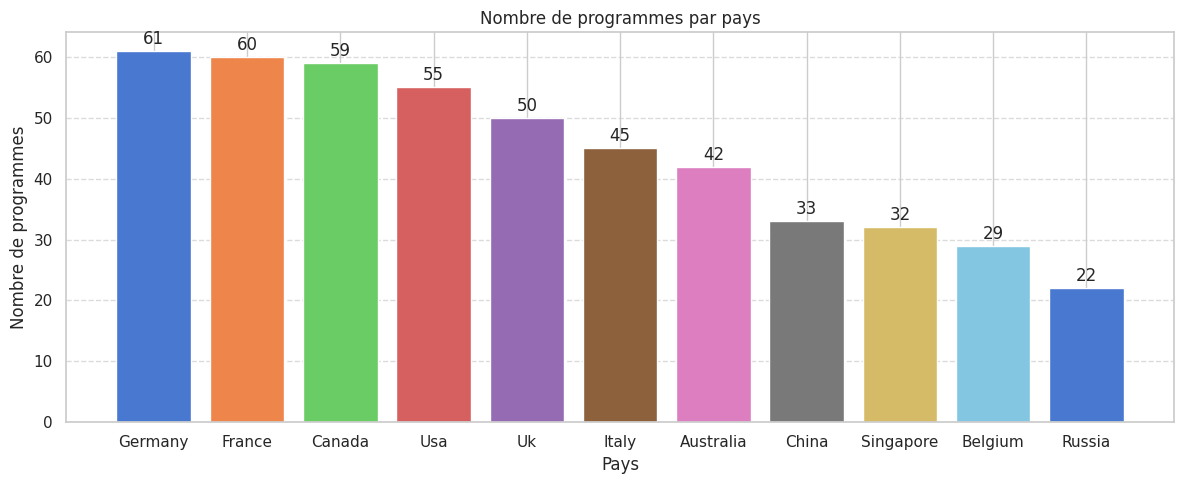

Répartition par pays :
           count   pct
COUNTRY               
Germany       61  12.5
France        60  12.3
Canada        59  12.1
Usa           55  11.3
Uk            50  10.2
Italy         45   9.2
Australia     42   8.6
China         33   6.8
Singapore     32   6.6
Belgium       29   5.9
Russia        22   4.5


In [ ]:
#répartition des programmes par pays
country_counts = df1['COUNTRY'].value_counts()
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(country_counts.index, country_counts.values,color=sns.color_palette('muted', len(country_counts)))

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,bar.get_height() + 0.5,str(int(bar.get_height())),ha='center', va='bottom')
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)

ax.set_title('Nombre de programmes par pays')
ax.set_xlabel('Pays')
ax.set_ylabel('Nombre de programmes')
plt.tight_layout()
plt.show()

print('Répartition par pays :')
print(country_counts.to_frame('count').assign(pct=lambda x: (x['count']/x['count'].sum()*100).round(1)))

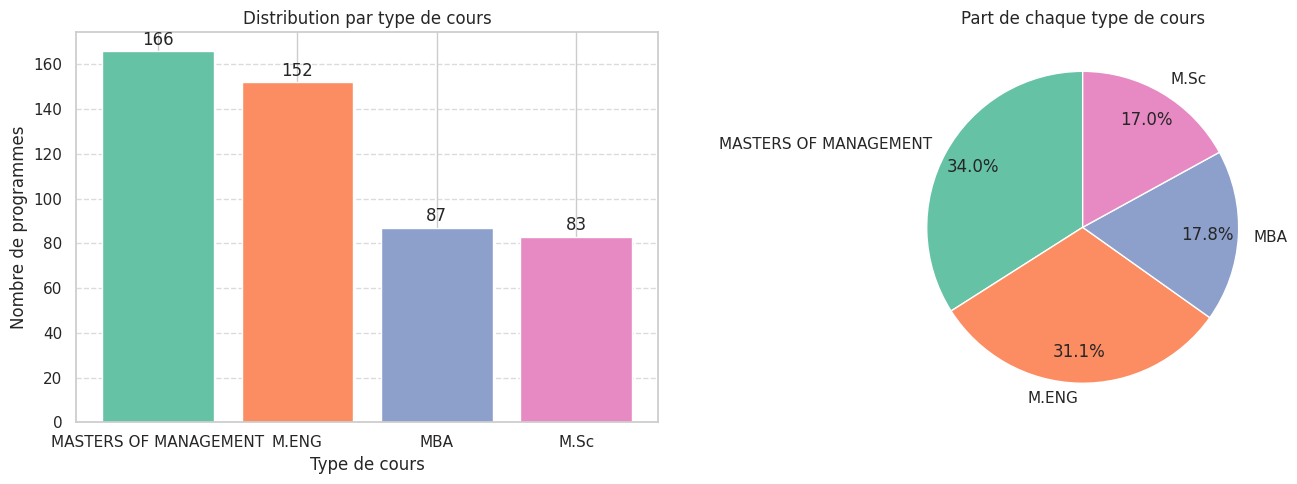

In [ ]:
course_counts = df1['COURSE_TYPE'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Barplot
bars = ax1.bar(course_counts.index, course_counts.values, color=sns.color_palette('Set2', 4))
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(int(bar.get_height())), ha='center', va='bottom')
ax1.grid(True, axis='y', linestyle='--', alpha=0.7)
ax1.set_title('Distribution par type de cours')
ax1.set_xlabel('Type de cours')
ax1.set_ylabel('Nombre de programmes')

# Pie chart
ax2.pie(course_counts.values, labels=course_counts.index, autopct='%1.1f%%', colors=sns.color_palette('Set2', 4), startangle=90, pctdistance=0.8)
ax2.set_title('Part de chaque type de cours')

plt.tight_layout()
plt.show()

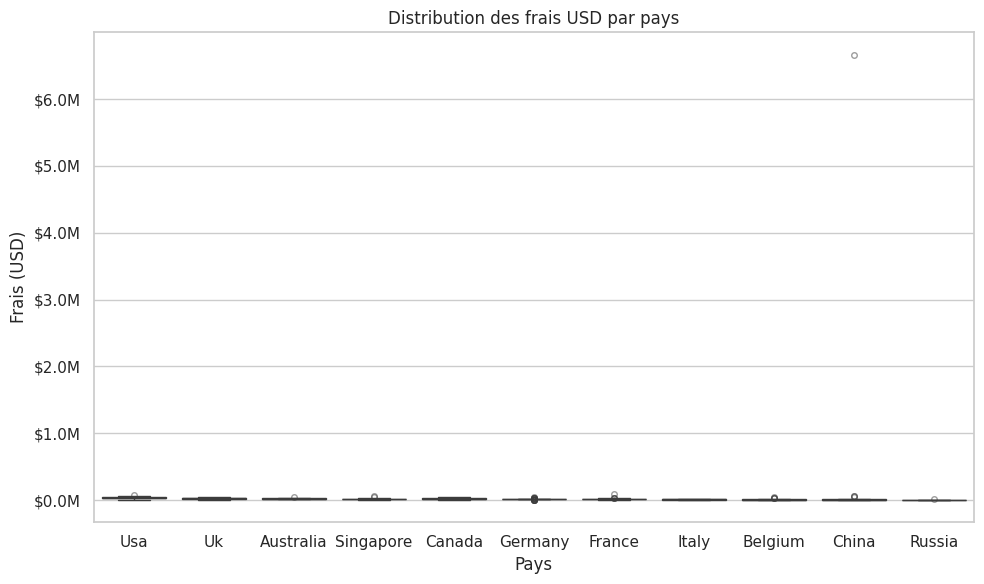

In [ ]:
order = df1.groupby('COUNTRY')['FEES_USD'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df1,x='COUNTRY', y='FEES_USD',order=order,palette='muted',flierprops=dict(marker='o', markersize=4, alpha=0.5),hue='COUNTRY',ax=ax)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_title('Distribution des frais USD par pays')
ax.set_xlabel('Pays')
ax.set_ylabel('Frais (USD)')
plt.tight_layout()
plt.savefig('boxplot_pays.png', bbox_inches='tight')
plt.show()

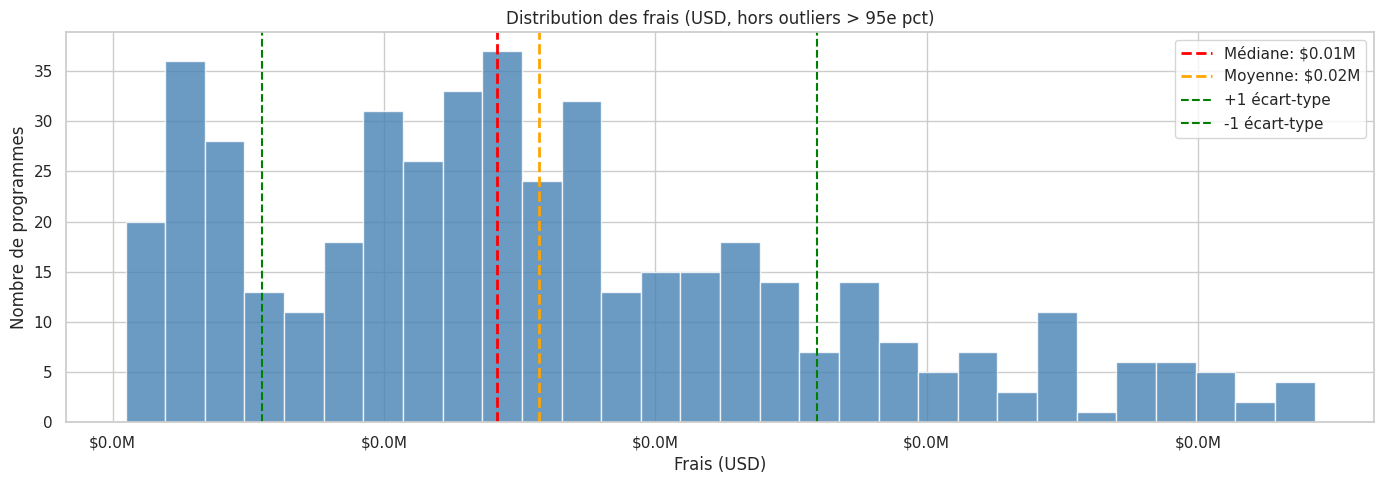

In [ ]:
# Histogramme (sans outliers extrêmes pour la lisibilité)
fig, ax1 = plt.subplots(figsize=(14, 5))
fees_95 = df1[df1['FEES_USD'] < df1['FEES_USD'].quantile(0.95)]['FEES_USD']
ax1.hist(fees_95, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax1.axvline(fees_95.median(), color='red', linestyle='--', linewidth=2, label=f'Médiane: ${fees_95.median()/1e6:.2f}M')
ax1.axvline(fees_95.mean(), color='orange', linestyle='--', linewidth=2, label=f'Moyenne: ${fees_95.mean()/1e6:.2f}M')
ax1.axvline(fees_95.mean() + fees_95.std(), color='green', linestyle='--', label='+1 écart-type')
ax1.axvline(fees_95.mean() - fees_95.std(), color='green', linestyle='--', label='-1 écart-type')
ax1.set_title('Distribution des frais (USD, hors outliers > 95e pct)')
ax1.set_xlabel('Frais (USD)')
ax1.set_ylabel('Nombre de programmes')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax1.legend()
plt.tight_layout()
plt.show()

#ce histogramme est réalisé hors outliers pour avoir des results plus lisible et claires sans etre affecter par des val des extremes
#et éviter des statistiques biaisées(moyennes et ecart-type)

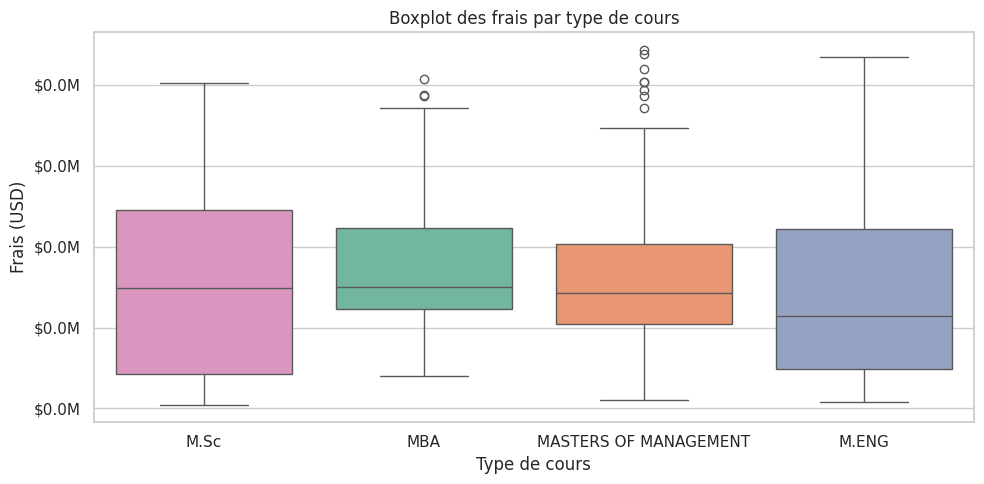

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
df_plot = df1[df1['FEES_USD'] < df1['FEES_USD'].quantile(0.95)]
order = df1.groupby('COURSE_TYPE')['FEES_USD'].median().sort_values(ascending=False).index
sns.boxplot(data=df_plot, x='COURSE_TYPE', y='FEES_USD', order=order,palette='Set2',hue='COURSE_TYPE', ax=ax)
ax.set_title('Boxplot des frais par type de cours')
ax.set_xlabel('Type de cours')
ax.set_ylabel('Frais (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

,Moyenne,Médiane,Min,Max,N
COUNTRY,,,,,
China,211876.0,3931.0,1557.0,6665731.0,33
Usa,34191.0,34714.0,2184.0,82012.0,55
Uk,24281.0,23871.0,5671.0,47522.0,50
Australia,21207.0,21320.0,13821.0,38583.0,42
Canada,19369.0,16419.0,4670.0,40778.0,59
Singapore,19068.0,17370.0,6266.0,62004.0,32
France,14405.0,11454.0,479.0,96993.0,60
Germany,14280.0,12932.0,958.0,38774.0,61
Belgium,10481.0,5714.0,848.0,38622.0,29


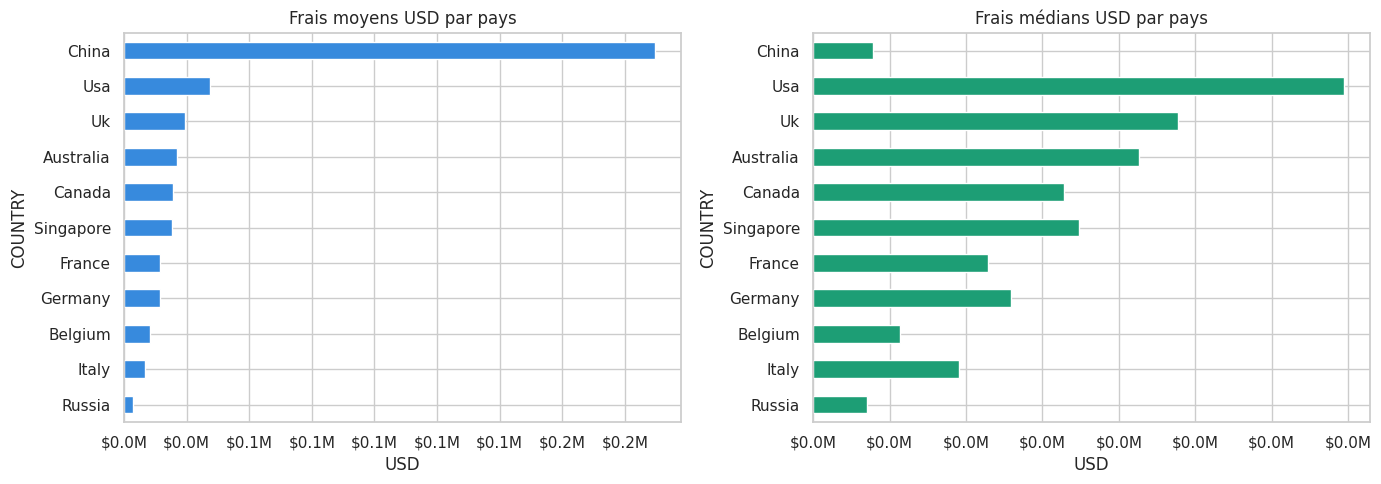

In [ ]:
#tab récap
country_stats = df1.groupby('COUNTRY')['FEES_USD'].agg(['mean','median','min','max','count']).round(0)
country_stats = country_stats.sort_values('mean', ascending=False)
country_stats.columns = ['Moyenne', 'Médiane', 'Min', 'Max', 'N']
display(country_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#frais moyens
country_stats['Moyenne'].plot(kind='barh', ax=axes[0], color='#378ADD')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].set_title('Frais moyens USD par pays')
axes[0].set_xlabel('USD')
axes[0].invert_yaxis()

#frais médians
country_stats['Médiane'].plot(kind='barh', ax=axes[1], color='#1D9E75')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[1].set_title('Frais médians USD par pays')
axes[1].set_xlabel('USD')
axes[1].invert_yaxis()

plt.tight_layout()

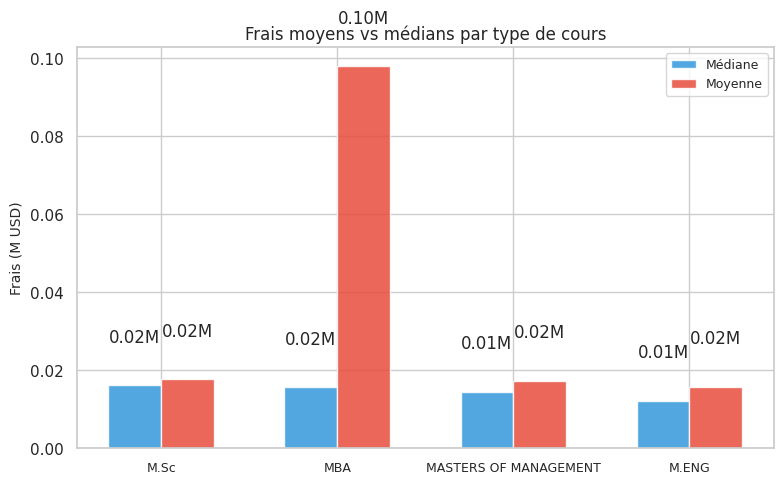

In [ ]:
#comparaison des frais par type de cours

course_stats = df1.groupby('COURSE_TYPE')['FEES_USD'].agg(['mean','median','min','max','count']).sort_values('median', ascending=False)
course_stats.columns = ['Moyenne', 'Médiane', 'Min', 'Max', 'Nb programmes']

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(course_stats))
width = 0.3
bars1 = ax.bar(x - width/2, course_stats['Médiane']/1e6, width, label='Médiane', color='#3498db', alpha=0.85)

bars2 = ax.bar(x + width/2, course_stats['Moyenne']/1e6, width, label='Moyenne', color='#e74c3c', alpha=0.85)

# Réduire taille du texte
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.2f}M', ha='center', va='bottom')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.2f}M', ha='center', va='bottom')

ax.set_xticks(x)
ax.set_xticklabels(course_stats.index, fontsize=9)

ax.set_title('Frais moyens vs médians par type de cours')
ax.set_ylabel('Frais (M USD)', fontsize=10)

ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


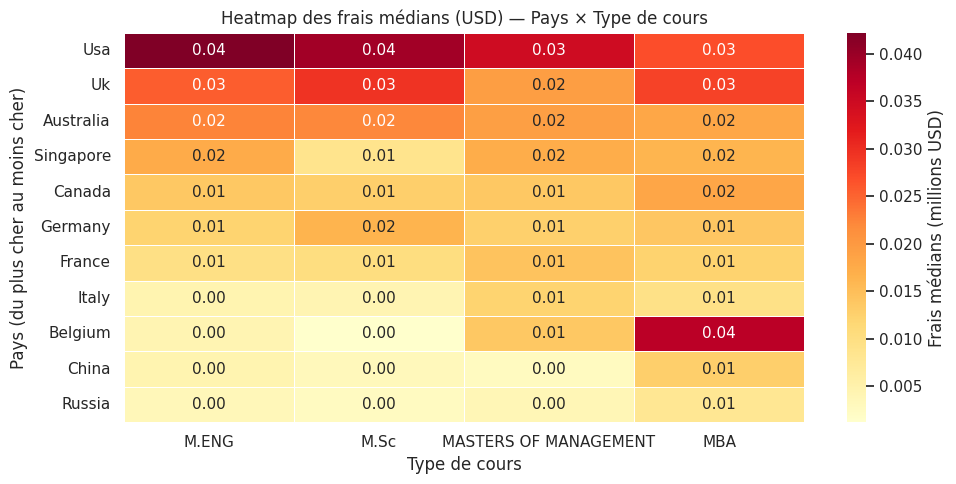

In [ ]:
pivot = df1.groupby(['COUNTRY', 'COURSE_TYPE'])['FEES_USD'].median().unstack(fill_value=np.nan)
#tri les pays par frais médian global (descending)
country_order = df1.groupby('COUNTRY')['FEES_USD'].median().sort_values(ascending=False).index
pivot = pivot.loc[country_order]

fig, ax = plt.subplots(figsize=(10, 5))
pivot_display = pivot / 1e6

sns.heatmap(pivot_display, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, ax=ax, cbar_kws={'label': 'Frais médians (millions USD)'}, annot_kws={'size': 11})

ax.set_title('Heatmap des frais médians (USD) — Pays × Type de cours')
ax.set_xlabel('Type de cours')
ax.set_ylabel('Pays (du plus cher au moins cher)')
plt.tight_layout()
plt.show()

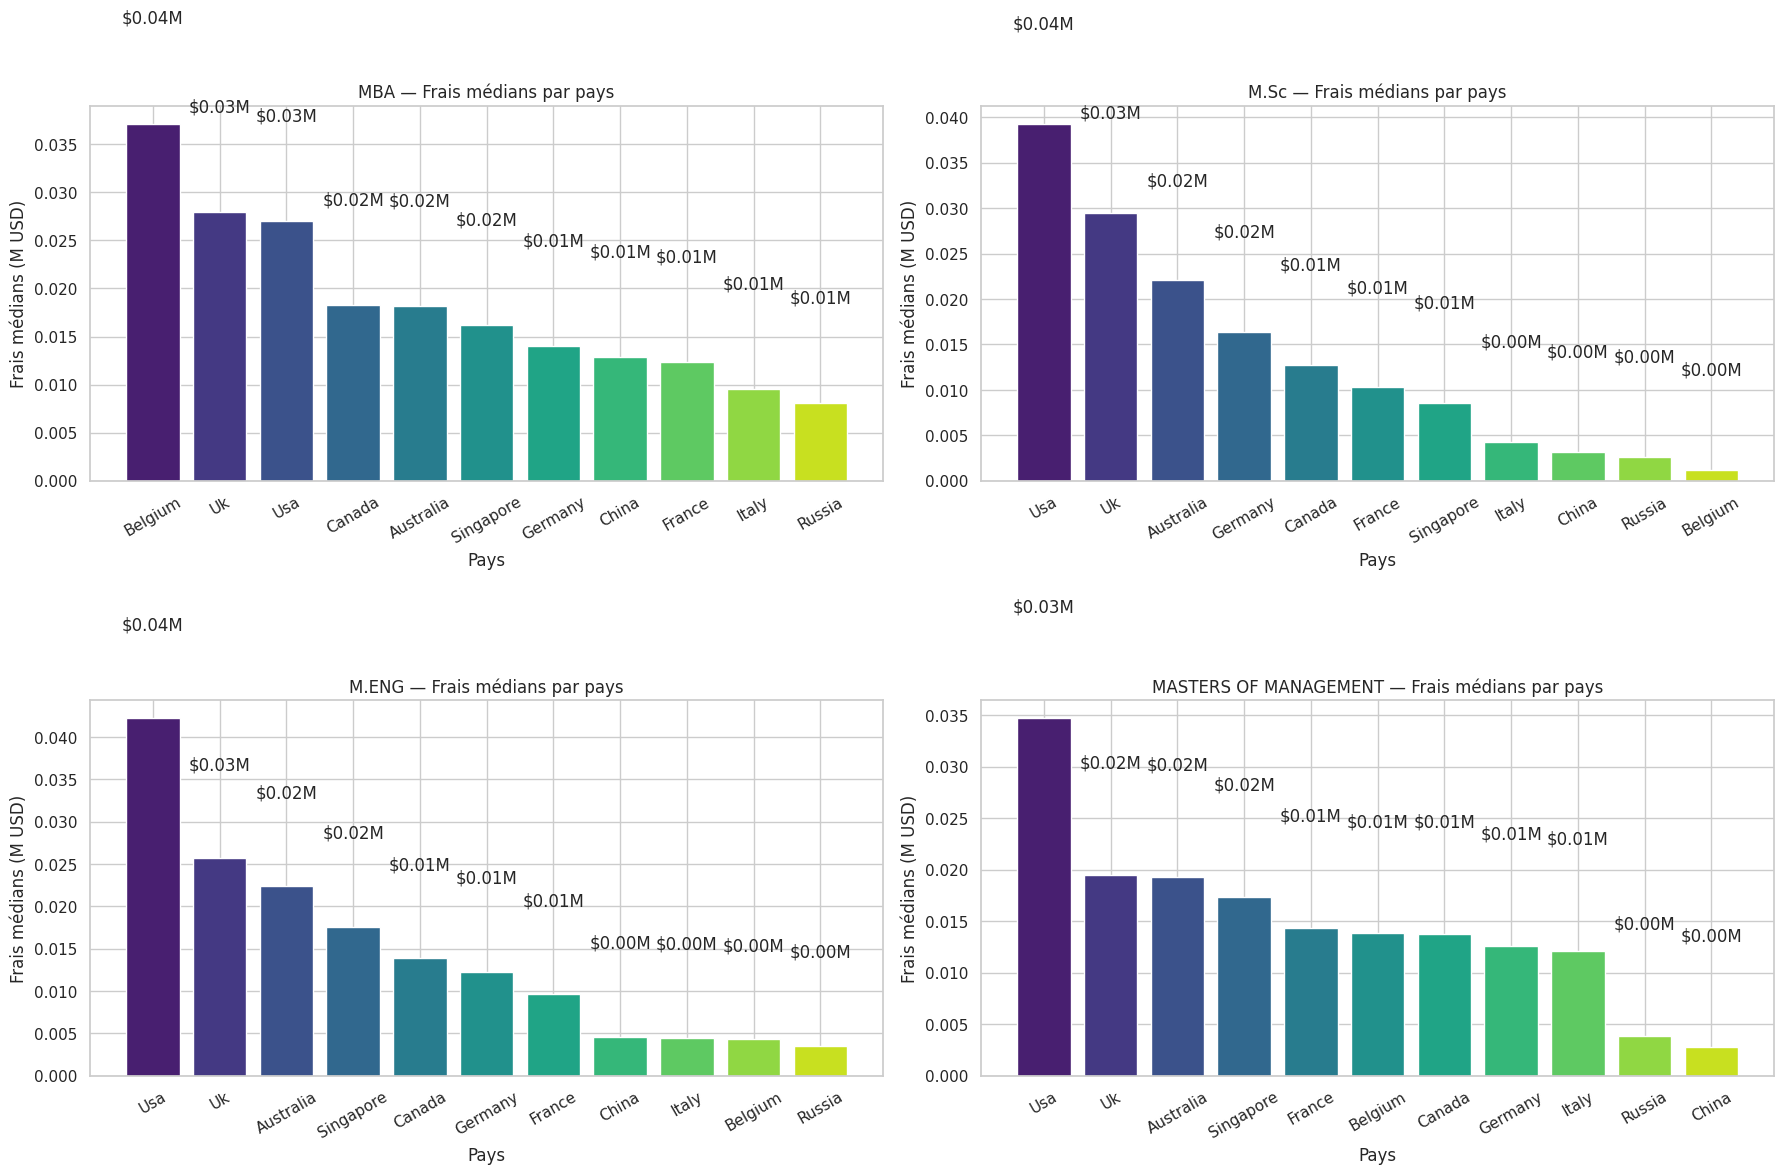

In [ ]:
#cout médians par pays pour chaque type de diplôme
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, ctype in enumerate(['MBA', 'M.Sc', 'M.ENG', 'MASTERS OF MANAGEMENT']):
    sub = df1[df1['COURSE_TYPE'] == ctype]
    stats = sub.groupby('COUNTRY')['FEES_USD'].median().sort_values(ascending=False)

    bars = axes[i].bar(stats.index, stats.values / 1e6, color=sns.color_palette('viridis', len(stats)))
    axes[i].set_title(f'{ctype} — Frais médians par pays')
    axes[i].set_xlabel('Pays')
    axes[i].set_ylabel('Frais médians (M USD)')
    axes[i].tick_params(axis='x', rotation=30)

    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'${bar.get_height():.2f}M',ha='center', va='bottom')

plt.tight_layout()
plt.show()

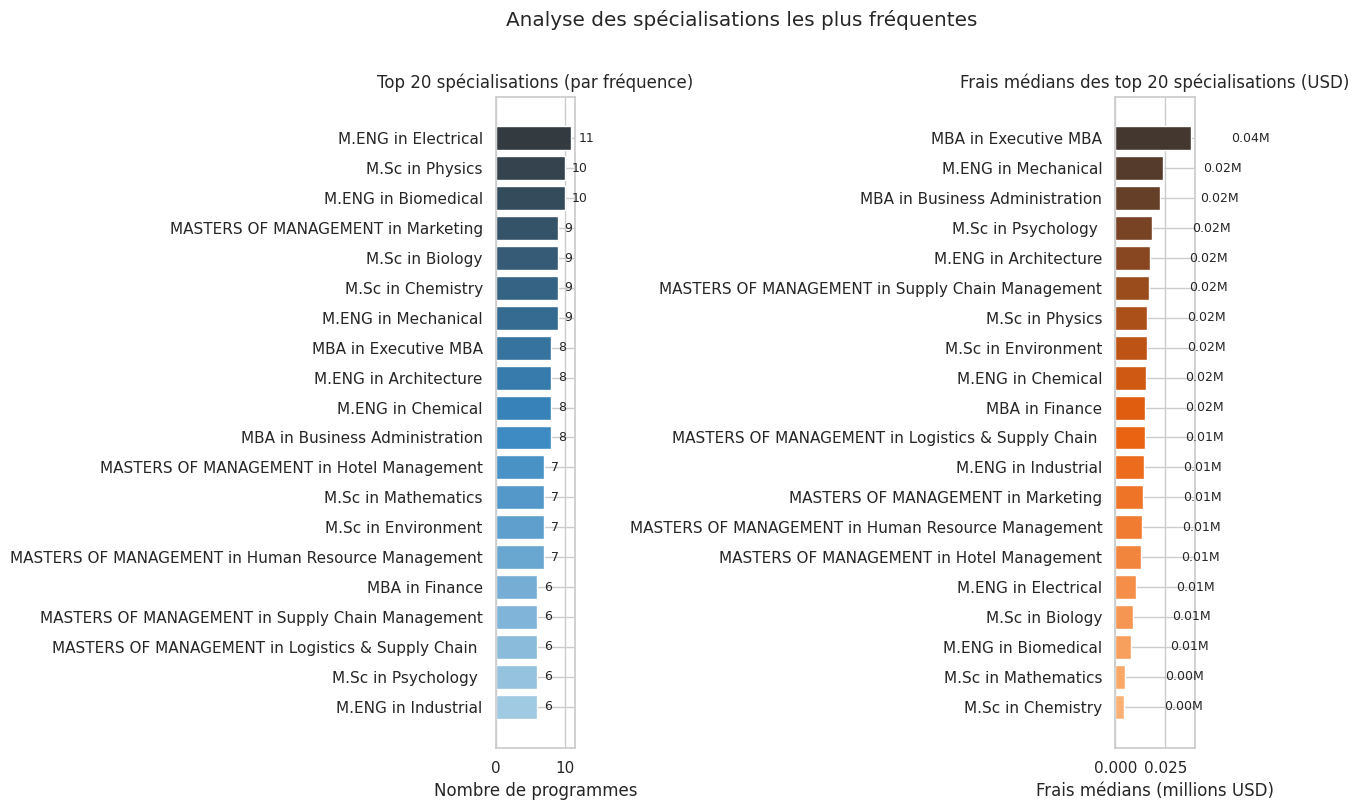

In [ ]:
#top 20 spécialisations par fréquence et cout médian
top_specs = df1['COURSE_(SPECIALIZATION)'].value_counts().head(20).index
spec_df = df1[df1['COURSE_(SPECIALIZATION)'].isin(top_specs)]
spec_stats = spec_df.groupby('COURSE_(SPECIALIZATION)').agg(count=('FEES_USD','count'),median_fees=('FEES_USD','median')).sort_values('count', ascending=True)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))

#fréquence
ax1.barh(spec_stats.index, spec_stats['count'], color=sns.color_palette('Blues_d', len(spec_stats)))
for i, v in enumerate(spec_stats['count']):
    ax1.text(v + 1, i, str(v), va='center', fontsize=9)
ax1.set_title('Top 20 spécialisations (par fréquence)')
ax1.set_xlabel('Nombre de programmes')

#cout médian
spec_stats_cost = spec_stats.sort_values('median_fees', ascending=True)
ax2.barh(spec_stats_cost.index, spec_stats_cost['median_fees']/1e6, color=sns.color_palette('Oranges_d', len(spec_stats_cost)))
for i, v in enumerate(spec_stats_cost['median_fees']/1e6):
    ax2.text(v + 0.02, i, f'{v:.2f}M', va='center', fontsize=9)
ax2.set_title('Frais médians des top 20 spécialisations (USD)')
ax2.set_xlabel('Frais médians (millions USD)')

plt.suptitle('Analyse des spécialisations les plus fréquentes', y=1.01)
plt.tight_layout()
plt.show()